# ゾンビ企業の早期予測モデル — 中日上場企業データによる機械学習

**財務データから1年先のゾンビ化を予測する二値分類プロジェクト**

中国・日本の上場企業（約8,000社、2016–2024年）の財務パネルデータを用いて、企業が翌年にゾンビ化するかを予測する。ケンブリッジ大学での修士研究を基盤とし、そこで用いたゾンビ企業識別理論（FN-CHK法）を予測特徴量へ転用している。

### 技術的なポイント
- **データリーク防止**：t年の特徴量で t+1年のラベルを予測する時間ずらし
- **ドメイン知識の特徴量化**：論文の金利ギャップ理論（CHK法）を予測特徴量へ
- **クラス不均衡**：正例約8%。PR-AUCを重視して評価
- **時系列分割**：過去（2016–2020）で学習し未来（2021–2022）を検証
- **説明可能性**：SHAPで重要な財務シグナルを可視化

## Part 1. データ統合
中国（主表・EBIT・利息明細）と日本（Osiris）の財務データを「企業-年」の統一フォーマットに整理し、縦に結合する。

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# ステップ１：データ統合（中国 + 日本）
# 目的：原始データを「企業-年」の統一フォーマットに整理
# ============================================================

DATA = 'data'  # データフォルダ

# ---------- 中国：主表（資産・負債など） ----------
df1 = pd.read_excel(f'{DATA}/111.xlsx', sheet_name='sheet1', dtype={'id':str})
df1 = df1[df1['type']=='A'].copy()
df1['date'] = pd.to_datetime(df1['date'])
df1 = df1[(df1['date'].dt.month==12) & (df1['date'].dt.day==31)].copy()
df1['year'] = df1['date'].dt.year
cn = df1[['id','year','AT','AR','AI','Bc1','BL','Liudongfuzhaiheji']].rename(columns={
    'AT':'total_assets', 'AR':'accounts_receivable', 'AI':'inventory',
    'Bc1':'short_borrow', 'BL':'long_debt', 'Liudongfuzhaiheji':'current_liab'})

# ---------- 中国：EBIT ----------
df2 = pd.read_excel(f'{DATA}/222.xlsx', sheet_name='sheet2', dtype={'id':str})
df2 = df2[df2['type']=='A'].copy()
df2['date'] = pd.to_datetime(df2['date'])
df2 = df2[(df2['date'].dt.month==12) & (df2['date'].dt.day==31)].copy()
df2['year'] = df2['date'].dt.year
ebit = df2[['id','year','EBIT']].copy()
ebit['EBIT'] = pd.to_numeric(ebit['EBIT'], errors='coerce')
cn = pd.merge(cn, ebit, on=['id','year'], how='left')

# ---------- 中国：利息（利息支出 - 利息収入） ----------
rc_raw = pd.read_excel(f'{DATA}/rc_interest.xlsx', header=1)
rc_raw.columns = ['Stkcd','Accper','Typrep','Sgnyea','item','amount']
rc_raw = rc_raw[~rc_raw['Stkcd'].isin(['证券代码','没有单位'])].copy()
rc_raw['Accper'] = pd.to_datetime(rc_raw['Accper'])
rc_raw = rc_raw[(rc_raw['Typrep']==1) & (rc_raw['Sgnyea']==1) &
                (rc_raw['Accper'].dt.month==12)].copy()
rc_raw['year'] = rc_raw['Accper'].dt.year
rc_raw['item'] = pd.to_numeric(rc_raw['item'], errors='coerce')
rc_raw['amount'] = pd.to_numeric(rc_raw['amount'], errors='coerce')
ie = rc_raw[rc_raw['item']==2][['Stkcd','year','amount']].rename(columns={'amount':'ie'})
ii = rc_raw[rc_raw['item']==3][['Stkcd','year','amount']].rename(columns={'amount':'ii'})
rc = pd.merge(ie, ii, on=['Stkcd','year'], how='outer')
rc = rc.groupby(['Stkcd','year']).agg(ie=('ie','max'), ii=('ii','max')).reset_index()
rc['interest'] = rc['ie'].fillna(0) - rc['ii'].fillna(0)
rc['id'] = rc['Stkcd'].astype(str).str.zfill(6)
cn = pd.merge(cn, rc[['id','year','interest']], on=['id','year'], how='left')

# 数値型に変換
for c in ['total_assets','accounts_receivable','inventory','short_borrow','long_debt','current_liab']:
    cn[c] = pd.to_numeric(cn[c], errors='coerce')

cn_std = pd.DataFrame({
    'firm':'CN_'+cn['id'].astype(str), 'year':cn['year'],
    'total_assets':cn['total_assets'], 'accounts_receivable':cn['accounts_receivable'],
    'inventory':cn['inventory'], 'short_borrow':cn['short_borrow'],
    'long_debt':cn['long_debt'], 'current_liab':cn['current_liab'],
    'EBIT':cn['EBIT'], 'interest':cn['interest'], 'country':'China'})

# ---------- 日本 ----------
jp = pd.read_excel(f'{DATA}/JP_data.xlsx', sheet_name='Sheet1')
ncols = ['TotalAssets','LongTermDebt','CurrentLiabilities','Accountsreceivable',
         'Netinventory','Financialexpenses','EBIT','LoansBorrowings',
         'Currentloansoverdrafts','Bankloans']
for c in ncols:
    jp[c] = pd.to_numeric(jp[c], errors='coerce')
jp = jp.sort_values(['BvDID','Year']).reset_index(drop=True)
for c in ncols:
    jp[c] = jp.groupby('BvDID')[c].ffill()
# 短期借入 = 当座借越 + 借入金 - 銀行借入（長期分）、負値は0にクリップ
jp['short_borrow'] = (jp['Currentloansoverdrafts'].fillna(0)
                    + jp['LoansBorrowings'].fillna(0)
                    - jp['Bankloans'].fillna(0)).clip(lower=0)

jp_std = pd.DataFrame({
    'firm':'JP_'+jp['BvDID'].astype(str), 'year':jp['Year'],
    'total_assets':jp['TotalAssets'], 'accounts_receivable':jp['Accountsreceivable'],
    'inventory':jp['Netinventory'], 'short_borrow':jp['short_borrow'],
    'long_debt':jp['LongTermDebt'], 'current_liab':jp['CurrentLiabilities'],
    'EBIT':jp['EBIT'], 'interest':jp['Financialexpenses'].fillna(0), 'country':'Japan'})

# ---------- 合併 ----------
data = pd.concat([cn_std, jp_std], ignore_index=True)

print(f'統合完了: {len(data)}行, {data["firm"].nunique()}社')
print(f'  中国: {(data["country"]=="China").sum()}行')
print(f'  日本: {(data["country"]=="Japan").sum()}行')
print(f'  期間: {data["year"].min()}-{data["year"].max()}')
print(f'\n各列の欠損率:')
for c in ['total_assets','long_debt','short_borrow','EBIT','interest']:
    print(f'  {c:20s}: {data[c].isna().mean()*100:.1f}%')

data.head()

統合完了: 58606行, 8201社
  中国: 35350行
  日本: 23256行
  期間: 2016-2024

各列の欠損率:
  total_assets        : 2.1%
  long_debt           : 14.1%
  short_borrow        : 13.3%
  EBIT                : 2.1%
  interest            : 5.2%


,firm,year,total_assets,accounts_receivable,inventory,short_borrow,long_debt,current_liab,EBIT,interest,country
0,CN_000001,2016,2.953434e+12,4.198460e+11,NaN,0.0,2.634640e+11,NaN,2.993500e+10,NaN,China
1,CN_000001,2017,3.248474e+12,4.252090e+11,NaN,NaN,3.424920e+11,NaN,3.015700e+10,NaN,China
2,CN_000001,2018,3.418592e+12,NaN,NaN,NaN,3.818840e+11,NaN,3.223100e+10,NaN,China
3,CN_000001,2019,3.939070e+12,NaN,NaN,NaN,5.137620e+11,NaN,3.624000e+10,NaN,China
4,CN_000001,2020,4.468514e+12,NaN,NaN,NaN,6.118650e+11,NaN,3.675400e+10,NaN,China


## Part 2. ゾンビ企業ラベルの構築と時間ずらし
FN-CHK法でゾンビ企業を識別する。基準利息（前年借入×市場金利）を中日それぞれの金利で計算し、実際の支払利息と比較する。その後、時間ずらしにより当年の特徴量へ翌年のラベルを対応させる（データリーク防止の核心）。

In [2]:
# ============================================================
# ステップ2-1：基準利息の計算に必要なラグ変数を作成
# ゾンビ判定には「前年の借入残高 × 市場金利」が必要なため、
# 前年の負債データを当年の行に対応させる
# ============================================================

#　企業・年でソート
data = data.sort_values(['firm','year']).reset_index(drop=True)

#　前年（t-1年）の負債・資産データを当年に結合するためのテーブル
lag = data[['firm','year','short_borrow','long_debt',
            'total_assets','accounts_receivable','inventory','current_liab']].copy()
lag['year'] = lag['year'] + 1   # 1年ずらす → t-1年のデータがt年に対応
lag = lag.rename(columns={
    'short_borrow'        : 'short_borrow_lag',
    'long_debt'           : 'long_debt_lag',
    'total_assets'        : 'total_assets_lag',
    'accounts_receivable' : 'ar_lag',
    'inventory'           : 'inventory_lag',
    'current_liab'        : 'current_liab_lag',
})

# 当年データに前年データを結合
data = pd.merge(data, lag, on=['firm','year'], how='left')

print(f'ラグ変数を追加後: {len(data)}行, {data.shape[1]}列')
print(f'\n前年データが存在する行の割合（2016年は前年なしなので欠損）:')
print(f'  long_debt_lag 欠損率: {data["long_debt_lag"].isna().mean()*100:.1f}%')

# 2016年（各企業の初年度）は前年データがないことを確認
data[data['firm']=='CN_000001'][['firm','year','long_debt','long_debt_lag']].head()


ラグ変数を追加後: 58606行, 17列

前年データが存在する行の割合（2016年は前年なしなので欠損）:
  long_debt_lag 欠損率: 27.3%


,firm,year,long_debt,long_debt_lag
0,CN_000001,2016,2.634640e+11,NaN
1,CN_000001,2017,3.424920e+11,2.634640e+11
2,CN_000001,2018,3.818840e+11,3.424920e+11
3,CN_000001,2019,5.137620e+11,3.818840e+11
4,CN_000001,2020,6.118650e+11,5.137620e+11


In [3]:
# ============================================================
# ステップ2-2：中国企業の基準利息と金利ギャップを計算
# 中国人民銀行の基準金利を使用
#   短期貸出 4.35% / 長期貸出 4.75% / 預金 1.5%
# ============================================================

# 中国のみ抽出して計算
is_cn = data['country'] == 'China'

# 基準利息 Rstar = 前年短期借入×短期金利 + 前年長期借入×長期金利
data.loc[is_cn, 'Rstar'] = (
    data.loc[is_cn, 'short_borrow_lag'].fillna(0) * 0.0435 +
    data.loc[is_cn, 'long_debt_lag'].fillna(0) * 0.0475
)

# 利息収入の調整 RB =（前年総資産 − 前年応収 − 前年在庫）× 預金金利
data.loc[is_cn, 'RB'] = (
    data.loc[is_cn, 'total_assets_lag'].fillna(0)
    - data.loc[is_cn, 'ar_lag'].fillna(0)
    - data.loc[is_cn, 'inventory_lag'].fillna(0)
) * 0.015

# 金利ギャップ = 実際利息 −（基準利息 − 利息収入調整）
data.loc[is_cn, 'gap'] = (
    data.loc[is_cn, 'interest']
    - (data.loc[is_cn, 'Rstar'] - data.loc[is_cn, 'RB'])
)

# 確認：中国企業のgapの分布
print('中国企業の金利ギャップ（gap）の統計:')
print(data.loc[is_cn, 'gap'].describe())

中国企業の金利ギャップ（gap）の統計:
count    3.232900e+04
mean     6.784749e+07
std      7.305620e+08
min     -1.008355e+10
25%      2.174578e+06
50%      1.602324e+07
75%      4.799348e+07
max      4.431875e+10
Name: gap, dtype: float64


In [4]:
# ============================================================
# ステップ2-3：日本企業の基準利息と金利ギャップを計算
# 日本銀行の平均約定金利（年度別）を使用
#   長期金利は過去5年平均を用いる
# ============================================================

# 日本銀行 短期・長期の平均約定金利（年度別）
RS = {2016:0.006645833, 2017:0.006081667, 2018:0.006018333, 2019:0.005930,
      2020:0.0046775, 2021:0.004325, 2022:0.004239167, 2023:0.00431, 2024:0.003975}
RL = {2016:0.008033333, 2017:0.008016667, 2018:0.007629167, 2019:0.007208333,
      2020:0.007705, 2021:0.007376667, 2022:0.007834167, 2023:0.008734167, 2024:0.00955}
RD = 0.00004  # 預金金利（日本はゼロ金利環境のため極小）

is_jp = data['country'] == 'Japan'

# 長期金利の過去5年平均を年度ごとに計算
def rl_5yr_avg(year):
    vals = [RL.get(year-n) for n in range(1, 6)]      # t-1〜t-5年
    vals = [v for v in vals if v is not None]          # 存在する年のみ
    return sum(vals)/len(vals) if vals else 0

# 各行の年度に応じた金利を割り当て
data.loc[is_jp, 'rs_lag'] = data.loc[is_jp, 'year'].map(lambda y: RS.get(y-1, 0))
data.loc[is_jp, 'rl_avg'] = data.loc[is_jp, 'year'].map(rl_5yr_avg)

# 基準利息 Rstar = 前年短期借入×短期金利 + 前年長期借入×長期5年平均金利
data.loc[is_jp, 'Rstar'] = (
    data.loc[is_jp, 'short_borrow_lag'].fillna(0) * data.loc[is_jp, 'rs_lag'] +
    data.loc[is_jp, 'long_debt_lag'].fillna(0)   * data.loc[is_jp, 'rl_avg']
)

# 利息収入の調整 RB
data.loc[is_jp, 'RB'] = (
    data.loc[is_jp, 'total_assets_lag'].fillna(0)
    - data.loc[is_jp, 'ar_lag'].fillna(0)
    - data.loc[is_jp, 'inventory_lag'].fillna(0)
) * RD

# 金利ギャップ
data.loc[is_jp, 'gap'] = (
    data.loc[is_jp, 'interest']
    - (data.loc[is_jp, 'Rstar'] - data.loc[is_jp, 'RB'])
)

print('日本企業の金利ギャップ（gap）の統計:')
print(data.loc[is_jp, 'gap'].describe())

日本企業の金利ギャップ（gap）の統計:
count    2.325600e+04
mean     3.145261e+03
std      6.896134e+04
min     -7.752434e+04
25%     -1.910394e+00
50%      2.285071e+01
75%      3.258783e+02
max      4.731783e+06
Name: gap, dtype: float64


In [5]:
# ============================================================
# ステップ2-4：FN-CHK法によるゾンビ企業ラベルの構築（中日共通）
# 判定条件（いずれかを満たせばゾンビ = 1）：
#   条件1：金利ギャップ<0 かつ EBIT<基準利息（利率優遇型）
#   条件2：EBIT<基準利息 かつ 前年負債>前年総資産の50%（高負債困境型）
# ============================================================

# 修正金利ギャップ gapm = EBIT − 基準利息（EBIT が基準利息を下回るか）
data['gapm'] = data['EBIT'] - (data['Rstar'] - data['RB'])

# 前年の総負債（前年流動負債 + 前年長期負債）
data['debt_lag'] = data['current_liab_lag'].fillna(0) + data['long_debt_lag'].fillna(0)

# CHK：金利ギャップ < 0
data['CHK'] = (data['gap'] < 0).astype(int)

# FN-CHK の2条件
cond1 = (data['CHK'] == 1) & (data['gapm'] <= 0)
cond2 = (data['gapm'] <= 0) & (data['debt_lag'] >= 0.5 * data['total_assets_lag'])

# いずれかを満たせばゾンビ
data['zombie'] = (cond1 | cond2).astype(int)

# 当年ゾンビ比率を確認（国別）
print('当年のゾンビ企業比率（FN-CHK）:')
print(data.groupby('country')['zombie'].mean().round(3))
print(f'\n全体: {data["zombie"].mean():.3f}')
print(f'\n年別のゾンビ比率:')
print(data.groupby(['country','year'])['zombie'].mean().round(3).unstack(0))

当年のゾンビ企業比率（FN-CHK）:
country
China    0.078
Japan    0.061
Name: zombie, dtype: float64

全体: 0.071

年別のゾンビ比率:
country  China  Japan
year                 
2016     0.008  0.000
2017     0.051  0.038
2018     0.071  0.046
2019     0.075  0.062
2020     0.080  0.106
2021     0.087  0.084
2022     0.107  0.070
2023     0.108  0.069
2024       NaN  0.075


In [6]:
# ============================================================
# ステップ2-5：時間ずらし（データリーク防止の核心）
# 当年の財務特徴量に「翌年のゾンビラベル」を対応させる
# t年の行の label = t+1年の zombie
# ============================================================

# 翌年のゾンビラベルを取り出す
nxt = data[['firm','year','zombie']].copy()
nxt['year'] = nxt['year'] - 1        # 年を1つ前にずらす → t+1年のzombieがt年に対応
nxt = nxt.rename(columns={'zombie':'label'})

# 当年データに翌年ラベルを結合
data = pd.merge(data, nxt, on=['firm','year'], how='left')

# labelが存在する行だけを学習に使う（翌年データがない行は除外）
ml = data[data['label'].notna()].copy()
ml['label'] = ml['label'].astype(int)

print(f'元データ: {len(data)}行')
print(f'学習可能サンプル（翌年ラベル有り）: {len(ml)}行')
print(f'\n予測ラベルの分布:')
print(f'  正例（翌年ゾンビ化）: {int(ml["label"].sum())} ({ml["label"].mean()*100:.1f}%)')
print(f'  負例: {int((ml["label"]==0).sum())} ({(ml["label"]==0).mean()*100:.1f}%)')
print(f'\n国別・年別の正例数:')
print(ml.groupby(['country','year'])['label'].agg(['count','sum']).head(20))

元データ: 58606行
学習可能サンプル（翌年ラベル有り）: 50404行

予測ラベルの分布:
  正例（翌年ゾンビ化）: 4145 (8.2%)
  負例: 46259 (91.8%)

国別・年別の正例数:
              count  sum
country year            
China   2016   3310  192
        2017   3725  273
        2018   3842  309
        2019   4107  368
        2020   4565  433
        2021   4958  562
        2022   5225  587
Japan   2016   2584   98
        2017   2584  119
        2018   2584  159
        2019   2584  275
        2020   2584  216
        2021   2584  181
        2022   2584  178
        2023   2584  195


In [7]:
# ============================================================
# 中間成果の保存（kernel再起動に備える）
# ============================================================

# 学習用データセット（時間ずらし済み、これが本番で使う）
ml.to_csv('ml_dataset_raw.csv', index=False, encoding='utf-8-sig')

# 全中間データ（デバッグ・確認用）
data.to_csv('data_full_intermediate.csv', index=False, encoding='utf-8-sig')

print('保存完了:')
print(f'  ml_dataset_raw.csv           … 学習用 {len(ml)}行')
print(f'  data_full_intermediate.csv   … 中間データ {len(data)}行')

保存完了:
  ml_dataset_raw.csv           … 学習用 50404行
  data_full_intermediate.csv   … 中間データ 58606行


## Part 3. 特徴量エンジニアリング
絶対額を比率へ変換し、企業規模によらず比較可能にする。負債構造・利息・収益性・動的トレンド・国籍の5観点から18特徴量を構築し、inf→NaN変換とWinsorization（1%/99%）で外れ値を処理する。

In [9]:
# ============================================================
# ステップ3-A：負債構造の特徴量（4つ）
# 絶対額を比率に変換し、企業規模によらず比較可能にする
# ============================================================

# 総負債 = 流動負債 + 長期負債
ml['total_debt'] = ml['current_liab'].fillna(0) + ml['long_debt'].fillna(0)

# 1. 資産負債率 = 総負債 / 総資産（全体のレバレッジ水準）
ml['debt_ratio'] = ml['total_debt'] / ml['total_assets']

# 2. 長期負債比率 = 長期負債 / 総負債（債務の期限構造）
ml['long_debt_ratio'] = ml['long_debt'] / ml['total_debt']

# 3. 長期負債資産比 = 長期負債 / 総資産（長期的な返済圧力）
ml['long_debt_asset'] = ml['long_debt'] / ml['total_assets']

# 4. 短期借入依存度 = 短期借入 / 総資産（短期債の回転依存）
ml['short_borrow_dep'] = ml['short_borrow'] / ml['total_assets']

# 確認
print('A類（負債構造）の特徴量の統計:')
print(ml[['debt_ratio','long_debt_ratio','long_debt_asset','short_borrow_dep']].describe().round(3))

KeyError: 'current_liab'

In [9]:
# ============================================================
# ステップ3-B：利息・返済能力の特徴量（4つ）
# ============================================================

# 有利子負債 = 短期借入 + 長期借入（利息を生む負債のみ）
ml['interest_debt'] = ml['short_borrow'].fillna(0) + ml['long_debt'].fillna(0)

# 1. 実効金利 = 利息費用 / 有利子負債（金利優遇の検出：高負債なのに低金利は異常）
ml['implied_rate'] = ml['interest'] / ml['interest_debt']

# 2. 金利ギャップ（標準化）= gap / 総資産（CHK理論の中核、規模で標準化）
ml['interest_gap'] = ml['gap'] / ml['total_assets']

# 3. インタレストカバレッジ = EBIT / 利息費用（返済能力、EBITと合わせて見る）
ml['interest_coverage'] = ml['EBIT'] / ml['interest']

# 4. 利息負担率 = 利息費用 / 総資産（利息が資産に占める比重）
ml['interest_burden'] = ml['interest'] / ml['total_assets']

print('B類（利息・返済能力）の特徴量の統計:')
print(ml[['implied_rate','interest_gap','interest_coverage','interest_burden']].describe().round(3))

B類（利息・返済能力）の特徴量の統計:
       implied_rate  interest_gap  interest_coverage  interest_burden
count     45493.000     46611.000          46606.000        46611.000
mean            NaN         0.004                NaN            0.002
std             NaN         0.025                NaN            0.035
min            -inf        -1.105               -inf           -0.783
25%           0.004         0.000              3.779            0.000
50%           0.010         0.001             21.026            0.001
75%           0.038         0.007             79.180            0.003
max             inf         5.085                inf            7.422


In [10]:
# ============================================================
# ステップ3-C：収益性の特徴量（3つ）
# 営業収入が両国で揃わないため、総資産を分母とするROAを収益性の中心指標として用いる
# ============================================================

# 1. ROA = EBIT / 総資産（資産収益性、収益力の中核指標）
ml['roa'] = ml['EBIT'] / ml['total_assets']

# 2. EBIT赤字フラグ（EBIT<0 なら1：直接的な赤字シグナル）
ml['ebit_negative'] = (ml['EBIT'] < 0).astype(int)

# 3. 在庫資産比 = 在庫 / 総資産（在庫の滞留、回転率の代理）
ml['inventory_ratio'] = ml['inventory'] / ml['total_assets']

print('C類（収益性）の特徴量の統計:')
print(ml[['roa','ebit_negative','inventory_ratio']].describe().round(3))
print(f'\nEBIT赤字企業の割合: {ml["ebit_negative"].mean()*100:.1f}%')

C類（収益性）の特徴量の統計:
             roa  ebit_negative  inventory_ratio
count  49180.000      50404.000        48079.000
mean       0.041          0.121            0.122
std        0.304          0.327            0.113
min      -30.688          0.000            0.000
25%        0.018          0.000            0.041
50%        0.047          0.000            0.099
75%        0.083          0.000            0.167
max        7.458          1.000            0.939

EBIT赤字企業の割合: 12.1%


In [11]:
# ============================================================
# ステップ3-D：動的トレンドの特徴量（6つ）
# 「変化の方向」を捉える。静的な水準では見えない「じわじわ悪化」を検出
# ============================================================

# 企業・年でソート（トレンド計算の前提）
ml = ml.sort_values(['firm','year']).reset_index(drop=True)

# 1. ROA前年差 = 今年ROA − 前年ROA（収益性が改善か悪化か）
ml['roa_change'] = ml.groupby('firm')['roa'].diff()

# 2. 総負債の前年比変化率（負債の急減=債務免除、該当なし=追い貸しを捉える）
ml['debt_growth'] = ml.groupby('firm')['total_debt'].pct_change()

# 3. 利息費用の前年比変化率（利息の急減=金利優遇シグナル）
ml['interest_growth'] = ml.groupby('firm')['interest'].pct_change()

# 4. EBIT前年比変化率（収益トレンド）
ml['ebit_growth'] = ml.groupby('firm')['EBIT'].pct_change()

# 5. 連続赤字年数（EBIT<0が何年続いているか：ゾンビの識別）
def consecutive_loss(s):
    result = []
    cnt = 0
    for v in s:
        cnt = cnt + 1 if v < 0 else 0
        result.append(cnt)
    return result
ml['loss_years'] = ml.groupby('firm')['EBIT'].transform(consecutive_loss)

# 6. ROAの3年ローリング標準偏差（変動性：もがく企業は変動大、ゾンビは平坦）
ml['roa_volatility'] = ml.groupby('firm')['roa'].transform(lambda x: x.rolling(3, min_periods=2).std())

print('D類（動的トレンド）の特徴量の統計:')
print(ml[['roa_change','debt_growth','interest_growth','ebit_growth','loss_years','roa_volatility']].describe().round(3))

D類（動的トレンド）の特徴量の統計:
       roa_change  debt_growth  interest_growth  ebit_growth  loss_years  \
count   41193.000    41538.000        38239.000    41193.000   50404.000   
mean       -0.006          inf              inf          NaN       0.200   
std         0.400          NaN              NaN          NaN       0.652   
min       -30.279       -1.000        -9213.932         -inf       0.000   
25%        -0.020       -0.067           -0.426       -0.419       0.000   
50%        -0.001        0.040           -0.049        0.000       0.000   
75%         0.013        0.232            0.344        0.294       0.000   
max        33.351          inf              inf          inf       8.000   

       roa_volatility  
count       41193.000  
mean            0.042  
std             0.292  
min             0.000  
25%             0.007  
50%             0.016  
75%             0.036  
max            20.388  


In [12]:
# ============================================================
# ステップ3-E：クリーニング（特徴量エンジニアリングの仕上げ）
#   1. inf → NaN（分母0による無限大を欠損に）
#   2. Winsorization（1%・99%分位で極端値を圧縮）
#   3. 国別特徴量の追加
# ============================================================

# 特徴量リスト（数値型のみ、Winsorization対象）
feature_cols = [
    # A 負債構造
    'debt_ratio','long_debt_ratio','long_debt_asset','short_borrow_dep',
    # B 利息・返済
    'implied_rate','interest_gap','interest_coverage','interest_burden',
    # C 収益性
    'roa','inventory_ratio',
    # D 動的トレンド
    'roa_change','debt_growth','interest_growth','ebit_growth','roa_volatility',
]

# --- 1. inf を NaN に置換 ---
ml[feature_cols] = ml[feature_cols].replace([np.inf, -np.inf], np.nan)

# --- 2. Winsorization（各特徴量を1%・99%分位でクリップ）---
for col in feature_cols:
    low  = ml[col].quantile(0.01)
    high = ml[col].quantile(0.99)
    ml[col] = ml[col].clip(lower=low, upper=high)

# --- 3. 国別特徴量（China=1, Japan=0）---
ml['is_china'] = (ml['country'] == 'China').astype(int)

# 最終的な特徴量リスト（二値・カウント系も加える）
all_features = feature_cols + ['ebit_negative','loss_years','is_china']

print(f'特徴量の総数: {len(all_features)}')
print(f'\nクリーニング後の統計:')
print(ml[feature_cols].describe().round(3))

特徴量の総数: 18

クリーニング後の統計:
       debt_ratio  long_debt_ratio  long_debt_asset  short_borrow_dep  \
count   49189.000        42588.000        42590.000         42744.000   
mean        0.397            0.193            0.089             0.089   
std         0.200            0.207            0.105             0.111   
min         0.047            0.000            0.000             0.000   
25%         0.237            0.024            0.007             0.002   
50%         0.384            0.129            0.049             0.049   
75%         0.538            0.300            0.135             0.133   
max         0.894            1.000            0.471             0.553   

       implied_rate  interest_gap  interest_coverage  interest_burden  \
count     41497.000     46611.000          45053.000        46611.000   
mean          0.179         0.004            128.862            0.002   
std           0.927         0.007            559.594            0.004   
min          -0.158       

In [13]:
# 最終的なモデリング 用データセットを保存
save_cols = ['firm','year','country','label'] + all_features
ml[save_cols].to_csv('ml_dataset_features.csv', index=False, encoding='utf-8-sig')
print(f'保存完了: ml_dataset_features.csv')
print(f'  {len(ml)}行 × {len(save_cols)}列')
print(f'  特徴量 {len(all_features)}個 + label')
print(f'\n最終確認 - 正例率: {ml["label"].mean()*100:.1f}%')

保存完了: ml_dataset_features.csv
  50404行 × 22列
  特徴量 18個 + label

最終確認 - 正例率: 8.2%


## Part 4. モデリング
同梱の ml_dataset_features.csv からはここ以降を実行可能。時系列分割の上で、ロジスティック回帰・ランダムフォレスト・XGBoostを比較する。不均衡データのためPR-AUCを主指標とする。

In [14]:
# ============================================================
# ステップ4-1：時系列でのデータ分割（ランダム分割はデータリークを招く）
#   訓練：2016-2020年（過去で学習）
#   テスト：2021-2022年（未来を予測）
# ============================================================
import pandas as pd
import numpy as np

# 保存した特徴量データセットを読み込み（kernel再起動後もここから再開可能）
ml = pd.read_csv('ml_dataset_features.csv')

# 特徴量リスト（18個）
all_features = [
    'debt_ratio','long_debt_ratio','long_debt_asset','short_borrow_dep',
    'implied_rate','interest_gap','interest_coverage','interest_burden',
    'roa','inventory_ratio',
    'roa_change','debt_growth','interest_growth','ebit_growth','roa_volatility',
    'ebit_negative','loss_years','is_china',
]

# 時系列で分割
train = ml[ml['year'] <= 2020].copy()
test  = ml[ml['year'] >= 2021].copy()

X_train = train[all_features]
y_train = train['label']
X_test  = test[all_features]
y_test  = test['label']

print('=== データ分割の結果 ===')
print(f'訓練データ（2016-2020）: {len(X_train):,}行, 正例率 {y_train.mean()*100:.1f}%')
print(f'テストデータ（2021-2022）: {len(X_test):,}行, 正例率 {y_test.mean()*100:.1f}%')
print(f'\n訓練の正例数: {int(y_train.sum())}')
print(f'テストの正例数: {int(y_test.sum())}')
print(f'\n特徴量数: {len(all_features)}')

=== データ分割の結果 ===
訓練データ（2016-2020）: 32,469行, 正例率 7.5%
テストデータ（2021-2022）: 17,935行, 正例率 9.5%

訓練の正例数: 2442
テストの正例数: 1703

特徴量数: 18


In [16]:
# ============================================================
# ステップ4-2：ベースラインモデル（ロジスティック回帰）
#   クラス不均衡には class_weight='balanced' で対処
#   欠損値は中央値で補完（ロジスティック回帰は欠損を扱えないため）
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# ロジスティック回帰は欠損値を扱えないため、中央値で補完
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

# 特徴量のスケールを揃える（ロジスティック回帰は変数のスケールに敏感）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

# モデル訓練（class_weight='balanced' で少数派を重視）
logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

# 予測
y_pred_proba = logreg.predict_proba(X_test_scaled)[:, 1]  # ゾンビである確率
y_pred = logreg.predict(X_test_scaled)                     # 0/1の判定

# 評価
print('=== ベースライン：ロジスティック回帰 ===')
print(f'AUC: {roc_auc_score(y_test, y_pred_proba):.4f}')
print(f'\n分類レポート:')
print(classification_report(y_test, y_pred, target_names=['健全','ゾンビ']))
print(f'混同行列:')
print(confusion_matrix(y_test, y_pred))

from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_pred_proba)
print(f'PR-AUC: {pr_auc:.4f}')
print(f'（ランダム基準 = 正例率 = {y_test.mean():.3f}）')

=== ベースライン：ロジスティック回帰 ===
AUC: 0.9266

分類レポート:
              precision    recall  f1-score   support

          健全       0.99      0.82      0.89     16232
         ゾンビ       0.34      0.88      0.49      1703

    accuracy                           0.82     17935
   macro avg       0.66      0.85      0.69     17935
weighted avg       0.92      0.82      0.86     17935

混同行列:
[[13285  2947]
 [  198  1505]]
PR-AUC: 0.5911
（ランダム基準 = 正例率 = 0.095）


In [1]:
import pandas as pd
import numpy as np

ml = pd.read_csv('ml_dataset_features.csv')

all_features = [
    'debt_ratio','long_debt_ratio','long_debt_asset','short_borrow_dep',
    'implied_rate','interest_gap','interest_coverage','interest_burden',
    'roa','inventory_ratio',
    'roa_change','debt_growth','interest_growth','ebit_growth','roa_volatility',
    'ebit_negative','loss_years','is_china',
]

train = ml[ml['year'] <= 2020].copy()
test  = ml[ml['year'] >= 2021].copy()
X_train, y_train = train[all_features], train['label']
X_test,  y_test  = test[all_features],  test['label']

print(f'訓練: {len(X_train):,}行 / テスト: {len(X_test):,}行')
print(f'訓練正例率: {y_train.mean()*100:.1f}% / テスト正例率: {y_test.mean()*100:.1f}%')

訓練: 32,469行 / テスト: 17,935行
訓練正例率: 7.5% / テスト正例率: 9.5%


In [2]:
# ============================================================
# ステップ4-3：3モデルの比較（ロジスティック回帰 / ランダムフォレスト / XGBoost）
#   不均衡対策：class_weight または scale_pos_weight
#   評価：AUC と PR-AUC を中心に
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

# 不均衡の比率（負例/正例）→ XGBoostのscale_pos_weightに使う
neg, pos = (y_train==0).sum(), (y_train==1).sum()
spw = neg / pos
print(f'不均衡比率 scale_pos_weight = {spw:.2f}\n')

results = {}

# ---------- モデル1：ロジスティック回帰（欠損補完＋標準化が必要）----------
imp = SimpleImputer(strategy='median')
scl = StandardScaler()
Xtr_lr = scl.fit_transform(imp.fit_transform(X_train))
Xte_lr = scl.transform(imp.transform(X_test))

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(Xtr_lr, y_train)
p_lr = lr.predict_proba(Xte_lr)[:,1]
results['ロジスティック回帰'] = (roc_auc_score(y_test,p_lr), average_precision_score(y_test,p_lr))

# ---------- モデル2：ランダムフォレスト（欠損は中央値補完）----------
Xtr_rf = imp.fit_transform(X_train)   # RFは標準化不要だが欠損は補完
Xte_rf = imp.transform(X_test)

rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                            max_depth=8, min_samples_leaf=20,
                            random_state=42, n_jobs=-1)
rf.fit(Xtr_rf, y_train)
p_rf = rf.predict_proba(Xte_rf)[:,1]
results['ランダムフォレスト'] = (roc_auc_score(y_test,p_rf), average_precision_score(y_test,p_rf))

# ---------- モデル3：XGBoost（欠損をそのまま扱える）----------
xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                    scale_pos_weight=spw, eval_metric='aucpr',
                    random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)   # 欠損補完不要
p_xgb = xgb.predict_proba(X_test)[:,1]
results['XGBoost'] = (roc_auc_score(y_test,p_xgb), average_precision_score(y_test,p_xgb))

# ---------- 比較表 ----------
print('='*50)
print(f'{"モデル":<20}{"AUC":>10}{"PR-AUC":>10}')
print('='*50)
for name,(auc,prauc) in results.items():
    print(f'{name:<20}{auc:>10.4f}{prauc:>10.4f}')
print('='*50)
print(f'{"(ランダム基準)":<20}{0.5:>10.4f}{y_test.mean():>10.4f}')

不均衡比率 scale_pos_weight = 12.30

モデル                        AUC    PR-AUC
ロジスティック回帰               0.9266    0.5911
ランダムフォレスト               0.9539    0.6716
XGBoost                 0.9481    0.6592
(ランダム基準)                0.5000    0.0950


## Part 5. 説明可能性（SHAP）
最良モデル（ランダムフォレスト）についてSHAPで特徴量重要度を可視化する。資産負債率とROAが突出し、利息関連（論文由来の金利ギャップを含む）が上位を占める。国籍の重要度は低く、ゾンビ化の財務的規則性は国境を越えて共通であることを示唆する。

SHAP値の計算完了
形状: (2000, 18)


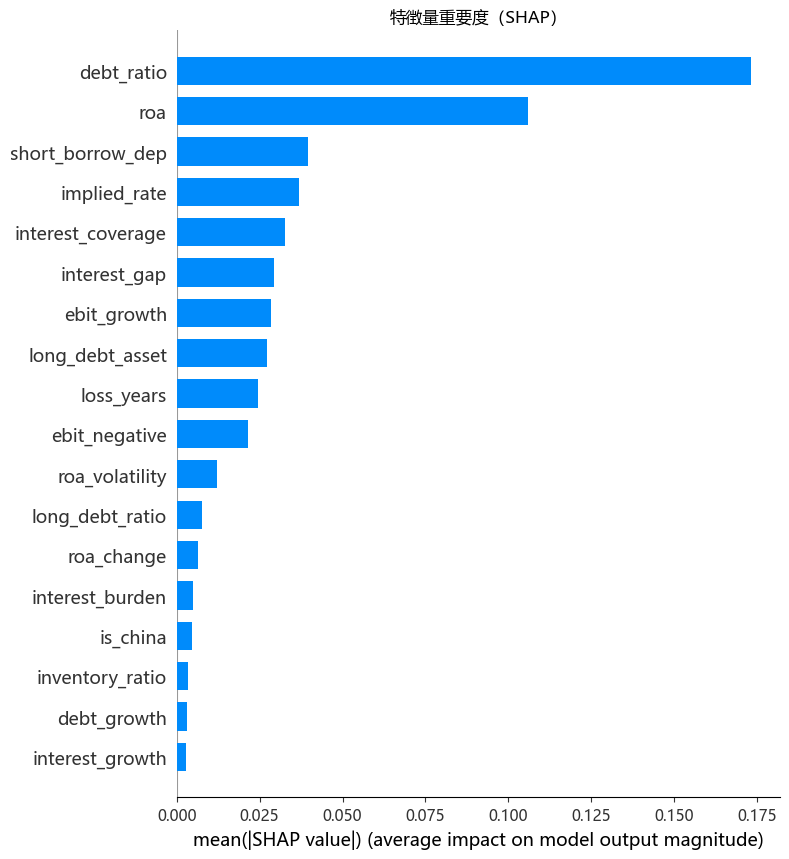

In [5]:
# ============================================================
# ステップ4-4：SHAP による特徴量重要度の分析（ランダムフォレスト使用）
#   モデルがどの財務シグナルを重視しているかを可視化
# ============================================================
import shap
import matplotlib.pyplot as plt
import matplotlib as mpl

# 日本語フォント設定
mpl.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'MS Gothic', 'Yu Gothic']
mpl.rcParams['axes.unicode_minus'] = False

# テストデータの欠損を補完（RFに合わせる）
X_test_imp = pd.DataFrame(imp.transform(X_test), columns=all_features)

# 計算量を抑えるため、テストから2000件をサンプリング
X_sample = X_test_imp.sample(n=2000, random_state=42)

# SHAP値を計算（ツリーモデル専用の高速なTreeExplainer）
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

# 二値分類の場合、shap_valuesはクラスごとに出る → クラス1(ゾンビ)を取る
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

print('SHAP値の計算完了')
print(f'形状: {sv.shape}')

# 全体的な特徴量重要度（棒グラフ）
shap.summary_plot(sv, X_sample, plot_type='bar', show=False)
plt.title('特徴量重要度（SHAP）')
plt.tight_layout()
plt.savefig('shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 6. エラー分析
モデルがどこで誤るかを分析する。偽陽性は高負債・低収益の境界線上の企業が中心。偽陰性は「表面上は財務改善だが、なお隠れた支援に依存するゾンビ」に集中し、本質的特徴量の必要性を裏づける。

D:\Programming\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


予測結果の分布:
result
TN    14152
FP     2080
TP     1551
FN      152
Name: count, dtype: int64

FP（誤判定）: 2080件
FN（見逃し）: 152件

=== 各グループの主要特徴量の平均 ===
        debt_ratio    roa  interest_gap  loss_years  ebit_growth  \
result                                                             
FN           0.505  0.043         0.002       0.118        0.444   
FP           0.597 -0.002         0.001       0.517       -0.787   
TN           0.334  0.063         0.005       0.136        0.025   
TP           0.652 -0.061         0.001       1.548       -1.433   

        roa_volatility  is_china  
result                            
FN               0.042     0.737  
FP               0.045     0.511  
TN               0.031     0.563  
TP               0.071     0.669  


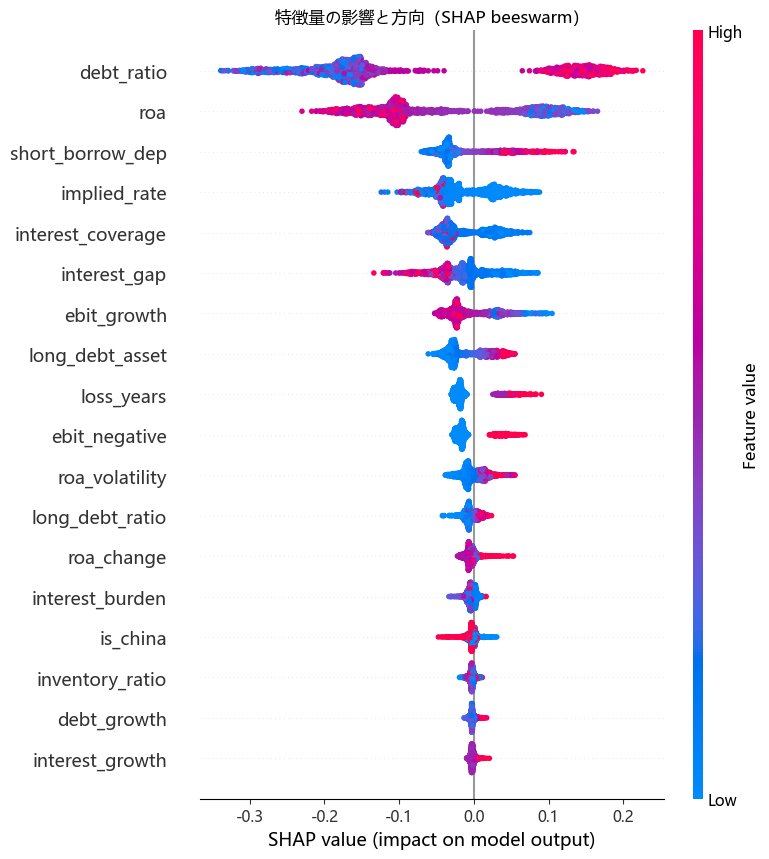

In [10]:
# ============================================================
# ステップ4-5：エラー分析（モデルがどこで間違うかを理解する）
#   FP（偽陽性）：健全企業を誤ってゾンビと判定 → 高新「偽ゾンビ」の可能性
#   FN（偽陰性）：真のゾンビを見逃し
# ============================================================

# ランダムフォレストの予測確率（テスト全体）
X_test_imp_full = pd.DataFrame(imp.transform(X_test), columns=all_features, index=X_test.index)
proba = rf.predict_proba(X_test_imp_full)[:, 1]
pred  = (proba >= 0.5).astype(int)

# テストデータに予測結果を結合
err = test.copy()
err['proba'] = proba
err['pred']  = pred
err['true']  = y_test.values

# 4象限に分類
err['result'] = 'TN'
err.loc[(err['true']==1)&(err['pred']==1), 'result'] = 'TP'  # 正しくゾンビ
err.loc[(err['true']==0)&(err['pred']==1), 'result'] = 'FP'  # 誤ってゾンビ
err.loc[(err['true']==1)&(err['pred']==0), 'result'] = 'FN'  # ゾンビ見逃し

print('予測結果の分布:')
print(err['result'].value_counts())
print(f'\nFP（誤判定）: {(err["result"]=="FP").sum()}件')
print(f'FN（見逃し）: {(err["result"]=="FN").sum()}件')

# FPとFNの特徴量を、正しく分類されたケースと比較
print('\n=== 各グループの主要特徴量の平均 ===')
compare_cols = ['debt_ratio','roa','interest_gap','loss_years','ebit_growth','roa_volatility','is_china']
print(err.groupby('result')[compare_cols].mean().round(3))

# ============================================================
# SHAP beeswarm（蜂群図）：重要度に加えて「方向」も可視化
#   点=企業、横位置=SHAP値（右=ゾンビへ、左=健全へ）、色=特徴量の値（赤=高、青=低）
# ============================================================

shap.summary_plot(sv, X_sample, show=False)   # plot_type指定なし＝デフォルトのbeeswarm
plt.title('特徴量の影響と方向（SHAP beeswarm）')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 7. ハイパーパラメータ調整
XGBoostをグリッドサーチ（訓練データ内の交差検証）で調整する。最適パラメータは保守的な側に収束し、質の高い特徴量の前ではモデルの複雑さの寄与は限定的であることが示された。最終的にランダムフォレストが最良（PR-AUC 0.67）。

In [7]:
# ============================================================
# ステップ4-6：XGBoostのハイパーパラメータ調整（グリッドサーチ）
#   訓練データ内での交差検証で最適パラメータを探索
#   テストデータは最後の評価まで一切使わない（リーク防止）
# ============================================================
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# 探索するパラメータの候補
param_grid = {
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'n_estimators':  [200, 400],
}

# ベースのXGBoost（不均衡対策のscale_pos_weightは固定）
xgb_base = XGBClassifier(
    scale_pos_weight=spw,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

# グリッドサーチ（5分割交差検証、PR-AUCで評価）
grid = GridSearchCV(
    xgb_base,
    param_grid,
    scoring='average_precision',   # PR-AUCで最適化
    cv=3,                          # 3分割交差検証（速度のため3に）
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

# 最適パラメータ
print('\n=== 最適パラメータ ===')
print(grid.best_params_)
print(f'交差検証でのPR-AUC: {grid.best_score_:.4f}')

# 最適モデルでテストデータを評価
best_xgb = grid.best_estimator_
p_best = best_xgb.predict_proba(X_test)[:, 1]
from sklearn.metrics import roc_auc_score, average_precision_score
print(f'\n=== テストデータでの評価 ===')
print(f'AUC:    {roc_auc_score(y_test, p_best):.4f}')
print(f'PR-AUC: {average_precision_score(y_test, p_best):.4f}')

print(f'\n=== 比較 ===')
print(f'調整前XGBoost PR-AUC: 0.6592')
print(f'ランダムフォレスト PR-AUC: 0.6716')
print(f'調整後XGBoost PR-AUC: {average_precision_score(y_test, p_best):.4f}')


Fitting 3 folds for each of 12 candidates, totalling 36 fits

=== 最適パラメータ ===
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
交差検証でのPR-AUC: 0.4595

=== テストデータでの評価 ===
AUC:    0.9520
PR-AUC: 0.6630

=== 比較 ===
調整前XGBoost PR-AUC: 0.6592
ランダムフォレスト PR-AUC: 0.6716
調整後XGBoost PR-AUC: 0.6630


## まとめ

| モデル | AUC | PR-AUC |
|--------|-----|--------|
| ロジスティック回帰 | 0.927 | 0.591 |
| **ランダムフォレスト** | **0.954** | **0.672** |
| XGBoost（調整後） | 0.952 | 0.663 |
| ランダム基準 | 0.500 | 0.095 |

1. **高い予測性能**：PR-AUC 0.67（ランダム基準の約7倍）
2. **特徴量 > モデル複雑さ**：単純なロジスティック回帰でもPR-AUC 0.59に到達
3. **理論との整合**：SHAPで論文のCHK理論が予測にも有効と確認
4. **国境を越える規則性**：国籍の重要度は低く、財務パターンは中日で共通